---
title: Multivariate > MDS Brand Maps
jupyter: python3
---

<div class="alert alert-info">Turn pairwise (dis)similarity judgments into a 2-D brand map using Multi-Dimensional Scaling (MDS).</div>

Brand maps based on (dis)similarity data can be analyzed using Multi-Dimensional Scaling (MDS).

In [1]:
import polars as pl
import pyrsm as rsm

In [2]:
## setup pyrsm for autoreload
%reload_ext autoreload
%autoreload 2
%aimport pyrsm

## Teaching Roadmap

This notebook walks through the full MDS workflow:

1. What (dis)similarity data looks like (long-format pairwise tables).
2. Metric MDS on intercity distances (a "ground-truth" example you can sanity-check against a map of the US).
3. Reading a brand map and interpreting the `Stress` measure of fit.
4. Flipping and relabeling axes to make a map easier to interpret.
5. Non-metric (rank-based) MDS on brand dissimilarity ratings.

In Radiant the MDS tool lives under _Multivariate > Maps > (Dis)similarity_. Here we drive the same engine directly from Python with `rsm.multivariate.mds`, so each setting becomes a function argument instead of a GUI control.

## Example 1 — Intercity Distances (Metric MDS)

The city data (`city`) contains information on distances in miles between 10 major cities in the US. Distances for 45 (10 x 9 / 2) from-to city pairs are provided. These data are used to illustrate that MDS can take simple data on distances (or on brand dissimilarities as we will see) and create a 2-dimensional map that accurately depicts the relative city (or brand) positions.

In Radiant you would go to _Data > Manage_, load the `examples` data, and select the `city` dataset; in _Multivariate > Maps > (Dis)similarity_ you would set `from` as ID 1, `to` as ID 2, and `distance` as the Dissimilarity measure, then click `Estimate model`. The Python equivalent is to read the parquet file and pass the same column names to `mds`.

In [3]:
city = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/city.parquet"
)
city.head()

from,to,distance
str,str,i32
"""Boston""","""Boston""",0
"""Boston""","""NY""",206
"""Boston""","""DC""",429
"""Boston""","""Miami""",1504
"""Boston""","""Chicago""",963


Notice the long format: each row is one pair of cities (`from`, `to`) and the distance between them (`distance`). This is the shape MDS expects — one row per pairwise comparison rather than a full square matrix.

In [4]:
m = rsm.multivariate.mds(
    {"city": city}, id1="from", id2="to", dis="distance", method="metric", nr_dim=2
)
m.summary()

(Dis)similarity based brand map (MDS)
Data        : city
Variables   : from, to, distance
Dimensions  : 2
Method      : Metric
Observations: 45

Original distance data:
shape: (9, 10)
┌─────────┬────────┬────────┬────────┬────────┬─────────┬─────────┬────────┬────────┬────────┐
│ label   ┆ Boston ┆ NY     ┆ DC     ┆ Miami  ┆ Chicago ┆ Seattle ┆ SF     ┆ LA     ┆ Denver │
│ ---     ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---     ┆ ---     ┆ ---    ┆ ---    ┆ ---    │
│ str     ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ f64     ┆ f64     ┆ f64    ┆ f64    ┆ f64    │
╞═════════╪════════╪════════╪════════╪════════╪═════════╪═════════╪════════╪════════╪════════╡
│ Boston  ┆ 0.0    ┆ 206.0  ┆ 429.0  ┆ 1504.0 ┆ 963.0   ┆ 2976.0  ┆ 3095.0 ┆ 2979.0 ┆ 1949.0 │
│ NY      ┆ 206.0  ┆ 0.0    ┆ 233.0  ┆ 1308.0 ┆ 802.0   ┆ 2815.0  ┆ 2934.0 ┆ 2786.0 ┆ 1771.0 │
│ DC      ┆ 429.0  ┆ 233.0  ┆ 0.0    ┆ 1075.0 ┆ 671.0   ┆ 2684.0  ┆ 2799.0 ┆ 2631.0 ┆ 1616.0 │
│ Miami   ┆ 1504.0 ┆ 1308.0 ┆ 1075.0 ┆ 0.0    ┆ 1329.0  

### Reading the summary

The original distances are shown in (lower triangular) matrix form above. If the analysis is successful we expect cities that are close (e.g., Washington DC and New York) to also be located close together on the map. Cities that are far apart (e.g., Seattle and Miami) should also be positioned far apart in the map.

The basic measure of (lack of) fit for MDS is called `Stress`. If MDS cannot create a map that accurately describes the original data this will result in high stress. Stress values of .1 are generally considered fair, .05 is good, and .01 or lower is excellent. High stress values indicate that a dimensionality of three (or higher) is needed to accurately depict the available data. For the city data the stress value is equal to .02 which is good. The summary also shows the coordinates that will be used to create the two-dimensional map and the recovered distances (i.e., how _far_ the cities are apart in the generated map).

You can also pull the stored fit statistics and coordinates directly:

In [5]:
print(f"Stress: {m.stress:.4f}")
m.coordinates()

Stress: 0.0197


label,Dim1,Dim2
str,f64,f64
"""Boston""",-1348.66833,-462.400598
"""NY""",-1198.874108,-306.5469
"""DC""",-1076.98554,-136.432035
"""Miami""",-1226.939011,1013.628384
"""Chicago""",-428.454833,-174.603165
"""Seattle""",1596.159402,-639.307769
"""SF""",1697.228281,131.685863
"""LA""",1464.04701,560.58046
"""Denver""",522.487129,13.395761


### The brand map

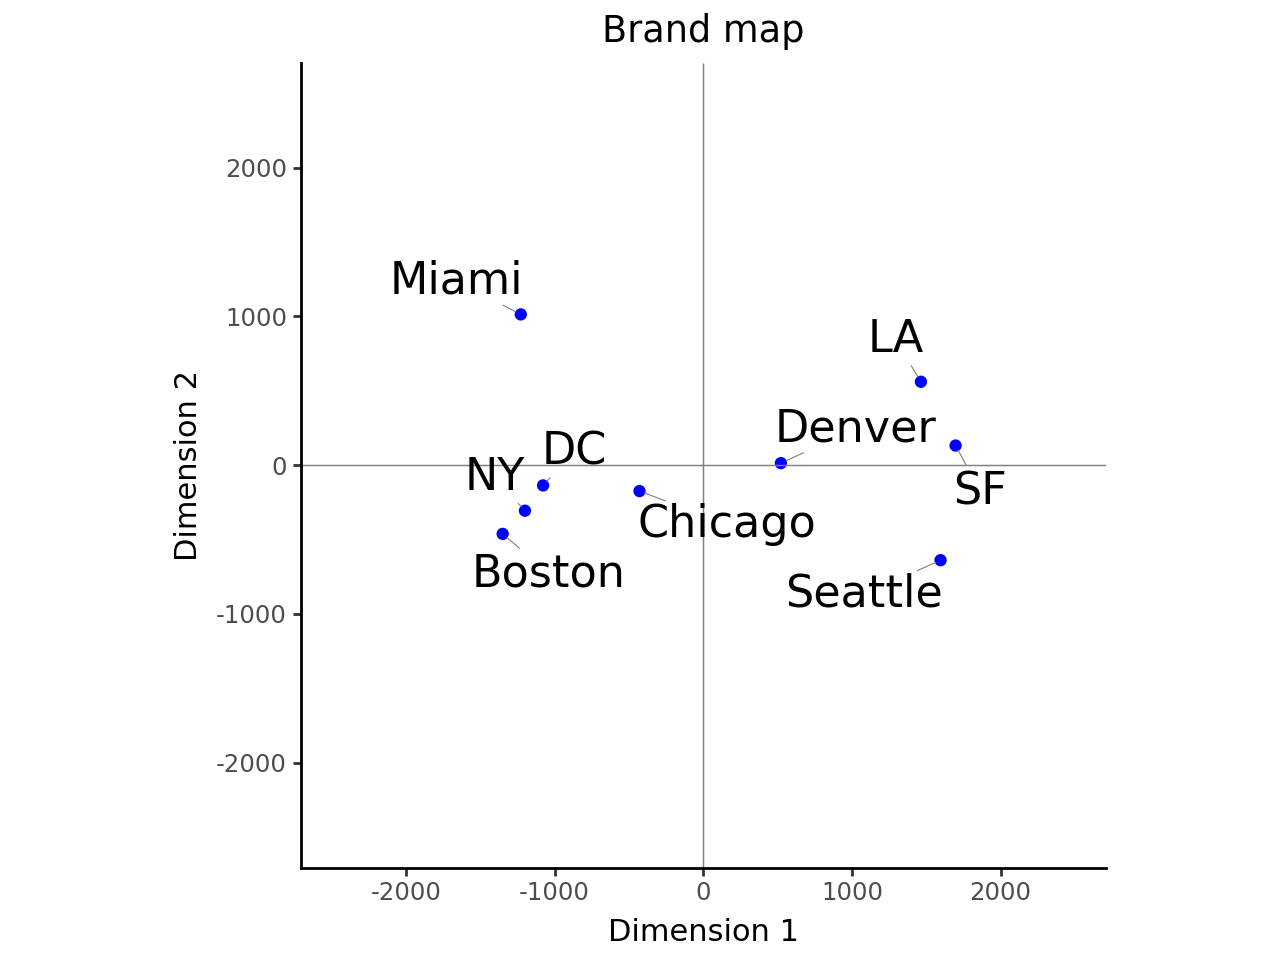

In [6]:
m.plot(fontsz=8)

In the plot above the relative locations of Los Angeles, Boston, etc. may look wrong. This is due to the fact that the MDS program has no information on North, South, East and West — MDS only recovers relative distances, so the solution is identified only up to rotation and reflection. We can _flip_ the plot to see if the map becomes easier to recognize and interpret.

### Flipping the axes

In Radiant you would click the check-boxes for `dimension 1` and `dimension 2` to flip the plot along the horizontal and vertical axes. In Python, pass `rev_dim` to `plot`. This flips the _rendered_ axes only — it does not mutate the stored coordinates, so you can experiment freely.

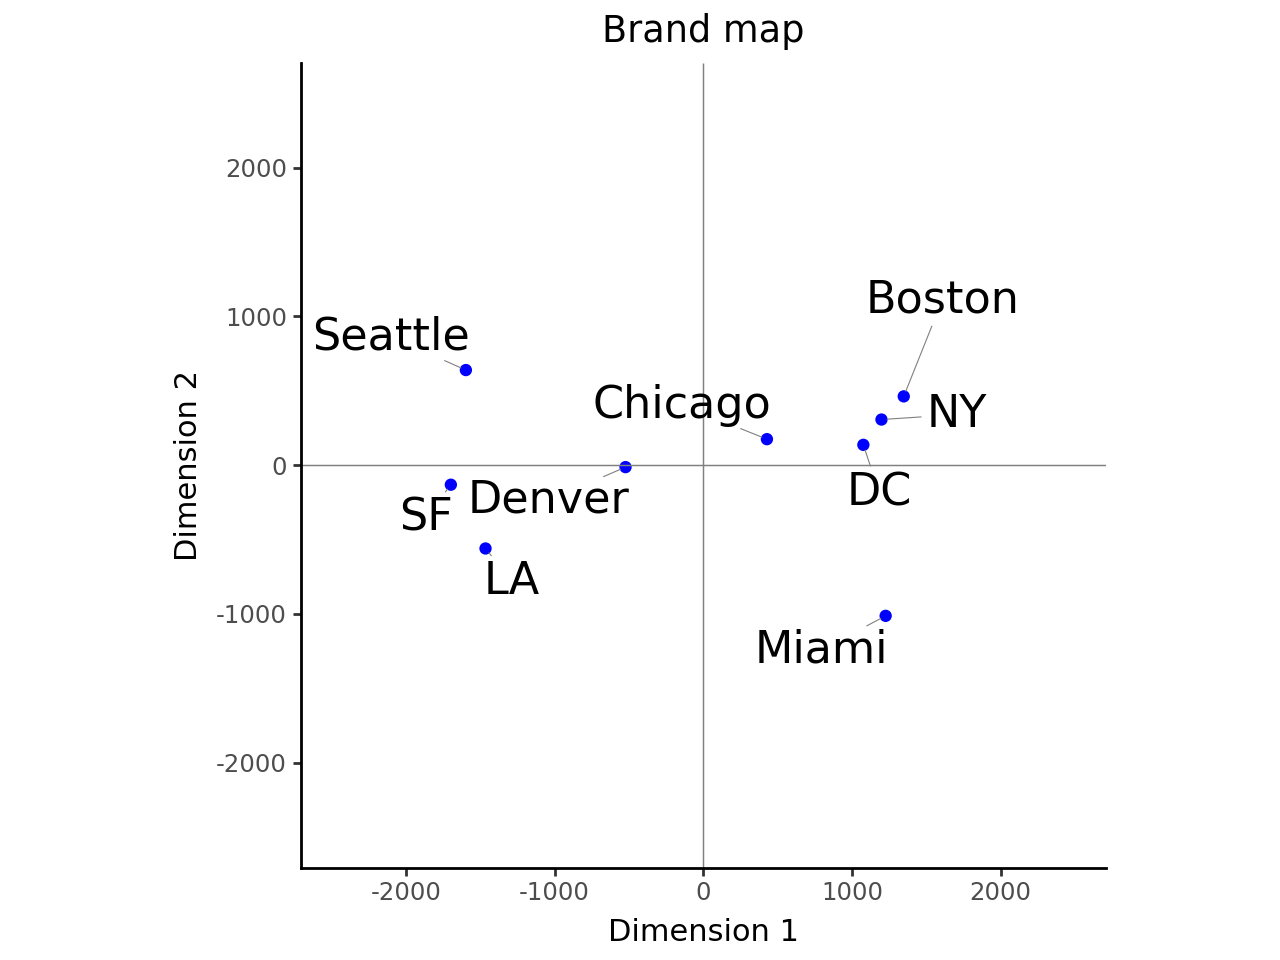

In [7]:
m.plot(rev_dim=[1, 2], fontsz=8)

After flipping the plot along both the horizontal and vertical axis we see that the relative locations of the cities look quite good — the map now resembles a familiar map of the US. Note that this map is _flat_, i.e., there is no correction for the curvature of the earth.

If you prefer to bake a reflection into the stored coordinates (so every subsequent plot and the coordinate table reflect it), use `m.flip(dims)` instead of the render-only `rev_dim` argument.

## Example 2 — Toothpaste Brands (Non-metric MDS)

The following analysis is based on similarity data for a set of toothpaste brands (`tpbrands` is available as one of the example datasets). Respondents were asked the following question: "Please rate the following pairs of toothpaste brands on the basis of their similarity (1 = very similar, 7 = very dissimilar)." for all pairwise combinations of 10 brands, i.e., 45 comparisons. MDS will try to create a map that reproduces, as accurately as possible, the original dissimilarities (or perceptual distances) provided by the 50 respondents.

With subjective ratings like these, the actual numeric spacing is less trustworthy than the _ordering_ of the dissimilarities. Non-metric MDS (an isoMDS-style approach) honors only the rank order of the dissimilarities rather than their exact magnitudes, which is usually the right choice for survey-based perceptual data.

In [8]:
tpbrands = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/tpbrands.parquet"
)
tpbrands.head()

id1,id2,dissimilarity,similarity
str,str,f64,f64
"""Crest""","""Aqua Fresh""",2.506726,5.493274
"""Crest""","""Colgate""",1.53973,6.46027
"""Crest""","""Aim""",3.304453,4.695547
"""Crest""","""Gleem""",4.823219,3.176781
"""Crest""","""Macleans""",4.841528,3.158472


In [9]:
mn = rsm.multivariate.mds(
    {"tpbrands": tpbrands}, id1="id1", id2="id2", dis="dissimilarity", method="non-metric"
)
mn.summary()

(Dis)similarity based brand map (MDS)
Data        : tpbrands
Variables   : id1, id2, dissimilarity
Dimensions  : 2
Method      : Non-metric
Observations: 45

Original distance data:
shape: (10, 11)
┌─────────────┬───────┬────────────┬─────────┬──────┬───────┬──────────┬─────────────┬──────────┬───────────┬───────────┐
│ label       ┆ Crest ┆ Aqua Fresh ┆ Colgate ┆ Aim  ┆ Gleem ┆ Macleans ┆ Ultra Brite ┆ Close Up ┆ Pepsodent ┆ Sensodyne │
│ ---         ┆ ---   ┆ ---        ┆ ---     ┆ ---  ┆ ---   ┆ ---      ┆ ---         ┆ ---      ┆ ---       ┆ ---       │
│ str         ┆ f64   ┆ f64        ┆ f64     ┆ f64  ┆ f64   ┆ f64      ┆ f64         ┆ f64      ┆ f64       ┆ f64       │
╞═════════════╪═══════╪════════════╪═════════╪══════╪═══════╪══════════╪═════════════╪══════════╪═══════════╪═══════════╡
│ Crest       ┆ 0.0   ┆ 2.51       ┆ 1.54    ┆ 3.3  ┆ 4.82  ┆ 4.84     ┆ 5.73        ┆ 5.61     ┆ 5.85      ┆ 7.0       │
│ Aqua Fresh  ┆ 2.51  ┆ 0.0        ┆ 1.0     ┆ 1.51 ┆ 4.31  ┆ 4.75    

The original dissimilarity ratings are shown in (lower triangular) matrix form above. From these data we can already see that the respondents perceive some brands to be very similar (e.g., Ultra Brite and Pepsodent have an average dissimilarity score of 1.11) and others to be very dissimilar (e.g., Crest and Sensodyne). The stress value for a two-dimensional solution is reasonable (.058). As we might expect, however, the original and recovered distances show that the fit is not as good as for the `city` data — real perceptual data is noisier than physical distances.

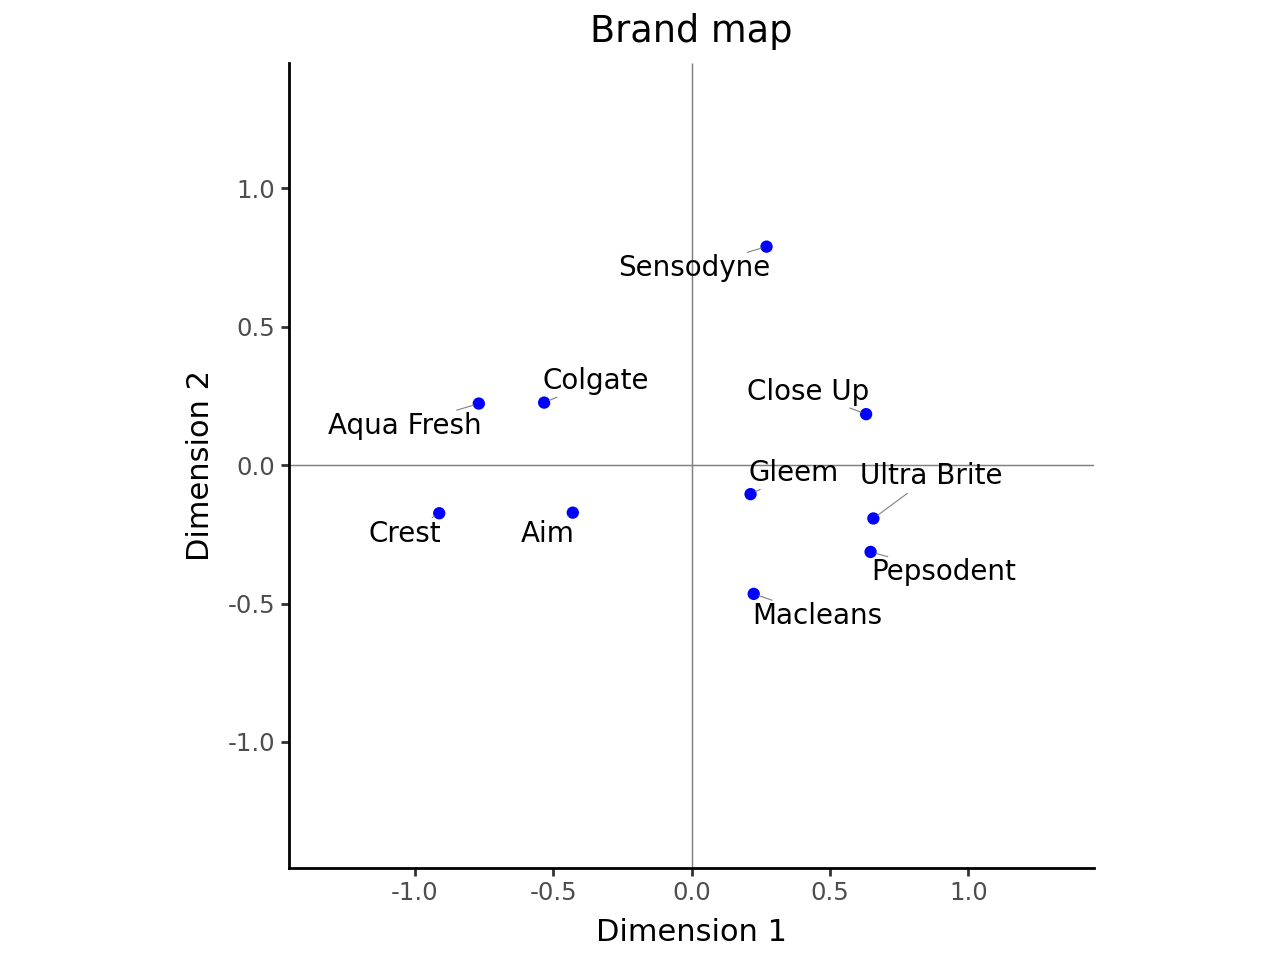

In [10]:
mn.plot()

### Interpreting the brand map

The coordinates shown in the summary are used to plot the brands in two dimensions. In the plot we see that Aqua Fresh and Colgate as well as Ultra Brite and Pepsodent are located very close together. This is consistent with the original data. Sensodyne and Crest, however, are positioned at opposite ends of the plot. Again, this is consistent with the original data and provides visual confirmation that MDS was able to create a plot that fits the data reasonably well.

From the plot a manager might conclude that the brands that are closest together in the map are perceived by consumers as close substitutes and, hence, close competitors in the minds of consumers in this market segment. A manager for Aqua Fresh or Macleans, in contrast, might focus less on Sensodyne when developing a competitive positioning plan for her brand.

An important limitation of brand maps based on (dis)similarity data is that the axes are difficult to interpret. For example, why are Close-up and Crest located at opposite ends along the horizontal axes? The researcher could ask respondents to explain the meaning of the axes or else obtain additional attribute information for the brands and correlate/overlay these on the plot to facilitate interpretation. Such attribute data could, however, also be used to create a brand map without the need for (dis)similarity ratings (see _Multivariate > Maps > Attributes_, exposed in Python as `rsm.multivariate.prmap`).

## Key Arguments and Attributes

Function arguments for `rsm.multivariate.mds`:

- `id1`, `id2` — the two ID columns identifying each pair.
- `dis` — the (dis)similarity column. Larger values must mean "more dissimilar / farther apart".
- `method` — `"metric"` (classical/cmdscale-style; treats dissimilarities as true distances) or `"non-metric"` (isoMDS-style; honors only the rank order).
- `nr_dim` — number of dimensions to recover. With `nr_dim >= 3` the plot shows one map per pair of dimensions.
- `seed` — random seed for reproducible non-metric solutions.
- `fontsz` — label font size in the plot.

Useful attributes and methods on the fitted object:

- `m.points` — the recovered coordinates as a NumPy array.
- `m.stress` — the stress (lack-of-fit) value; lower is better.
- `m.labels` — the brand/city labels in coordinate order.
- `m.dis_mat` — the reconstructed dissimilarity matrix.
- `m.coordinates()` — coordinates as a tidy DataFrame.
- `m.recovered_dist()` — the distances implied by the recovered map (compare against the originals).
- `m.flip(dims)` — permanently reflect the stored coordinates along the given dimension(s).
- `m.plot(rev_dim=[...])` — flip the rendered axes for display only, without mutating the stored coordinates.

## Discussion Prompts

- Why is the orientation of an MDS map arbitrary, and what does that imply about interpreting the raw axis labels?
- The city map has stress near .02 while the toothpaste map is near .058. What does that tell you about how well two dimensions capture each dataset, and when would you try `nr_dim=3`?
- For a brand manager, which brand pairs in the toothpaste map represent the most direct competition, and where might there be a positioning gap?
- When should you prefer non-metric MDS over metric MDS for survey-based similarity ratings?